# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data pandas/yulu_rental.csv')

In [ ]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [ ]:
print(df.size)
print(df.shape)
print(df.iloc[0])

206834
(10886, 19)
season                  1
holiday                 0
workingday              0
weather                 1
temp                 9.84
atemp              14.395
humidity               81
windspeed             0.0
casual                  3
registered             13
count                  16
date           2011-01-01
day                     1
week                   52
weekday_num             5
weekday          Saturday
year                 2011
month                   1
hour                    0
Name: 2011-01-01 00:00:00, dtype: object


Висновок
Розмір датафрейму. Кількість рядків - 10866, кількість стовпців - 19.
Рівень деталізації - годинний (один рядок - одна година спостереження)

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [91]:
daily_counts = df.groupby('date')['count'].sum()
daily_counts.index = pd.to_datetime(daily_counts.index)

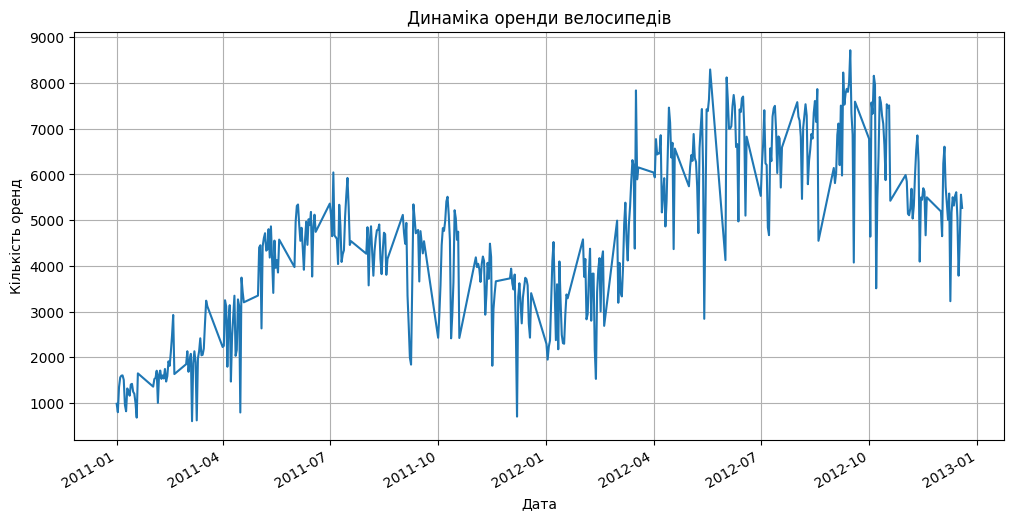

In [92]:
daily_counts.plot(
    figsize = (12,6), title = 'Динаміка оренди велосипедів',
    grid = True,
    xlabel = 'Дата',
    ylabel = 'Кількість оренд'
)
plt.show()

1. Заломи на графіку присутні, ьо оренда велосипедів дуже чутлива щодо щоденних даних. Можна наприклад зрупувати дані по тижнів або місяців.
2. Кількість оренд у 2012 році є більшою, що може свідчити про зростання популярності сервісу або розширення інфраструктури.
3. Найвищі показники спостерігаються в середині кожного року. Мінімуми припадають на січень-лютий та листопад-грудень. У холодну пору року попит природно падає.


datetime
2011-01-31     23552
2011-02-28     32844
2011-03-31     38735
2011-04-30     50517
2011-05-31     79713
2011-06-30     89776
2011-07-31     92848
2011-08-31     83296
2011-09-30     79104
2011-10-31     79522
2011-11-30     70889
2011-12-31     61183
2012-01-31     56332
2012-02-29     66269
2012-03-31     94766
2012-04-30    116885
2012-05-31    120434
2012-06-30    130957
2012-07-31    121769
2012-08-31    130220
2012-09-30    133425
2012-10-31    127912
2012-11-30    105551
2012-12-31     98977
Freq: ME, Name: count, dtype: int64


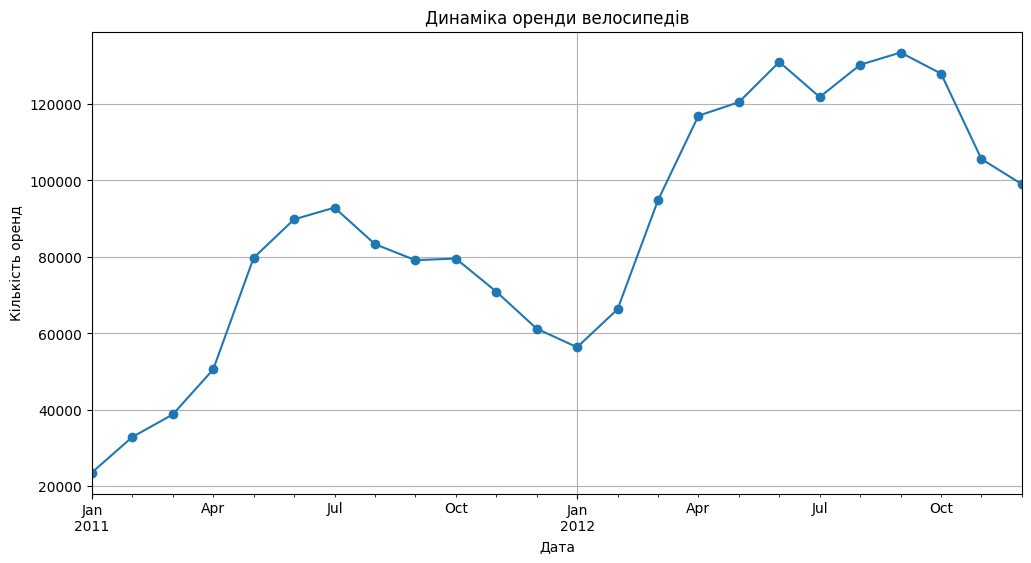

In [ ]:
monthly_counts = df['count'].resample('ME').sum()
print(monthly_counts)
monthly_counts.plot(
    figsize = (12,6), title = 'Динаміка оренди велосипедів',
    grid = True,
    xlabel = 'Дата',
    ylabel = 'Кількість оренд',
    marker='o'
)
plt.show()


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

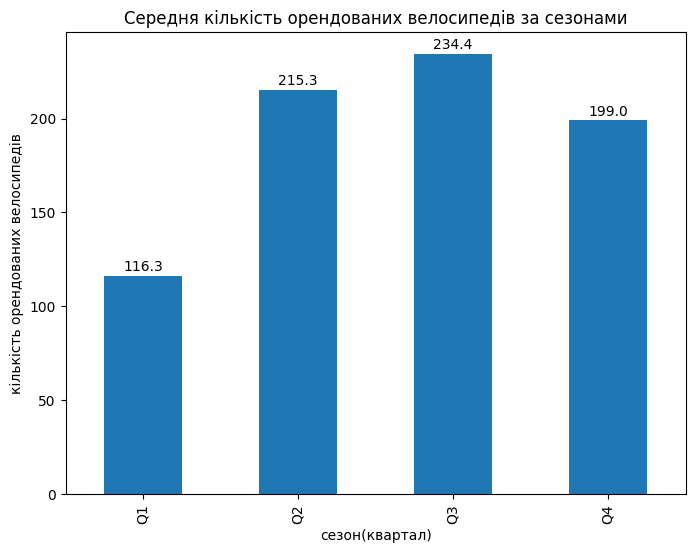

In [ ]:
season_mean = df.groupby('season')['count'].mean()
season_mean.index = ['Q1', 'Q2', 'Q3', 'Q4']
ax = season_mean.plot.bar(
    figsize=(8, 6),
    title='Середня кількість орендованих велосипедів за сезонами',
    xlabel='сезон(квартал)',
    ylabel='кількість орендованих велосипедів'
)
for i, v in enumerate(season_mean):
    ax.text(i, v + 1, f"{v:.1f}", ha='center', va='bottom')
plt.show()

In [ ]:
max_rent = season_mean.max()
min_rent = season_mean.min()
ratio = max_rent / min_rent
print(ratio)

2.0148749597441986


1. Найбільша середня кількість оренд спостерігається у Q3.
2. Тому, що найтепліший період року. Сприятлива температура та відсутність снігу роблять поїздки комфортними.
3. Оренда між найпопулярнішим та найменш популярним кварталми відрізняється у 2,01

Результат відповідно до індійської системи сезонів

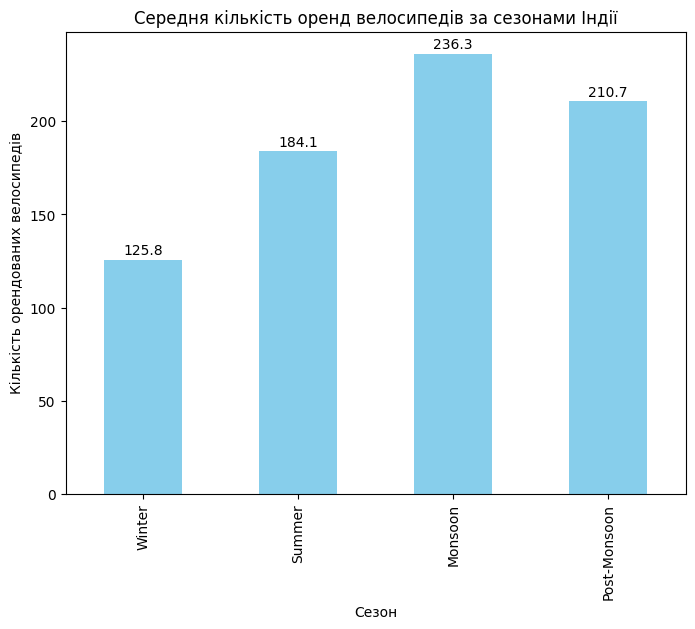

In [ ]:
def map_india_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11]:
        return 'Post-Monsoon'

df['weather_season_india'] = df['month'].apply(map_india_season)
india_season_mean = df.groupby('weather_season_india')['count'].mean()
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
india_season_mean = india_season_mean.reindex(season_order)
ax = india_season_mean.plot.bar(
    figsize=(8,6),
    title='Середня кількість оренд велосипедів за сезонами Індії',
    xlabel='Сезон',
    ylabel='Кількість орендованих велосипедів',
    color='skyblue'
)
for i, v in enumerate(india_season_mean):
    ax.text(i, v + 1, f"{v:.1f}", ha='center', va='bottom')

plt.show()

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


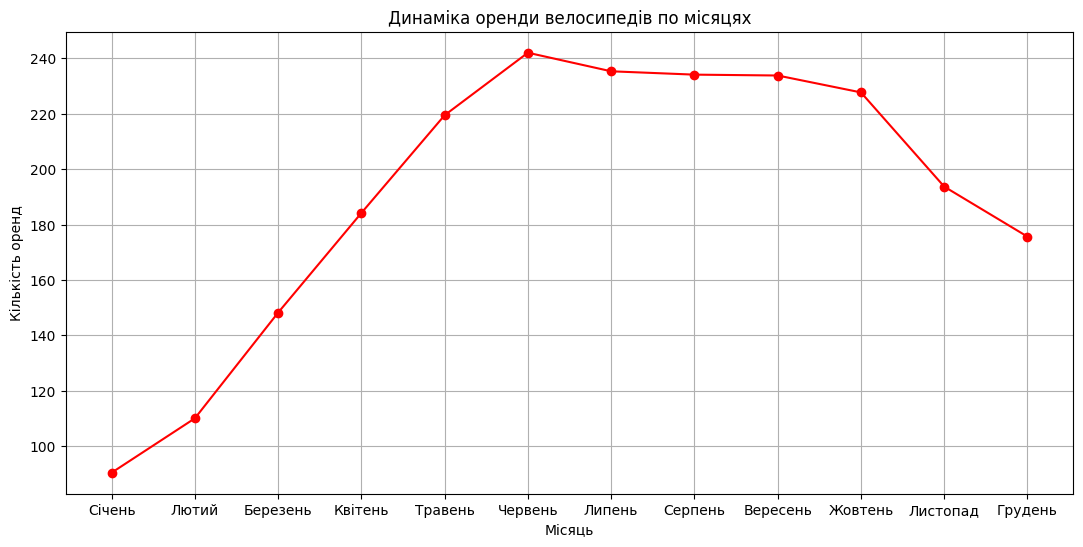

In [ ]:
avg_rentals = df.groupby('month')['count'].mean()
ax = avg_rentals.plot.line(
    figsize = (13,6),
    title = 'Динаміка оренди велосипедів по місяцях',
    grid = True,
    xlabel = 'Місяць',
    ylabel = 'Кількість оренд',
    marker='o',
    color = 'red'
)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Січень', 'Лютий', 'Березень', 'Квітень', 'Травень', 'Червень', 'Липень', 'Серпень', 'Вересень', 'Жовтень', 'Листопад', 'Грудень'])
plt.show()

1. Пік оренди спостерігається у червні, а спад у січні.
2. Так, ця закономірність повністю збігається з результатами аналізу по кварталах.
3. Клімат є визначальним фактором для цього бізнесу (температурний режим, опади та світловий день)

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

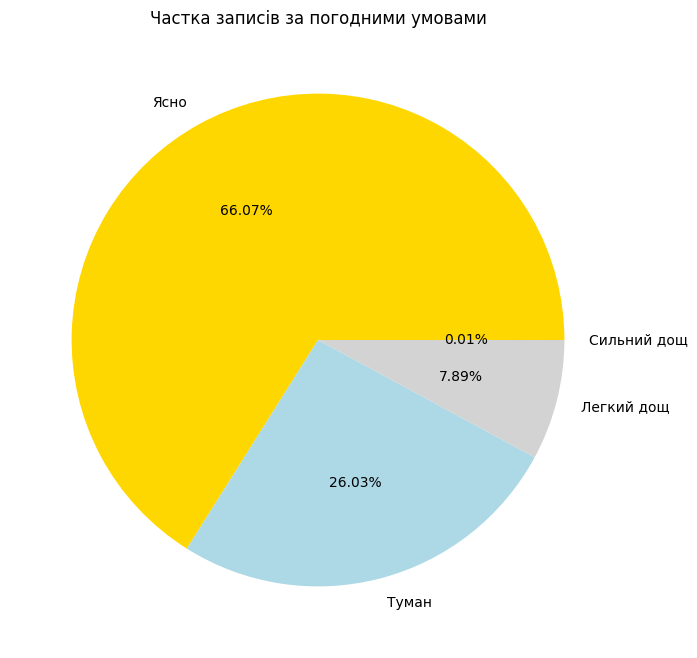

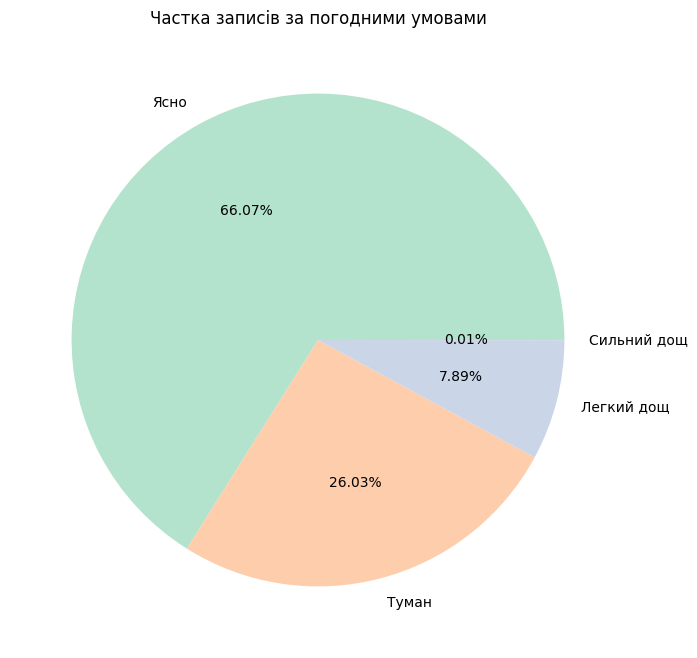

In [ ]:
weather_share = df['weather'].value_counts().sort_index()
weather_share.plot.pie(
    figsize = (20,8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title = 'Частка записів за погодними умовами',
    colors=plt.cm.Pastel2.colors,
    ylabel = ''
)
plt.show()

1. У датасеті переважає ясна погода.
2. Дні із сильним дощем у датасеті є, проте їхня кількість надзвичайно мала (0,01).
3. Погодні умови є одним із критичних факторів впливу на оренду велосипедів

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

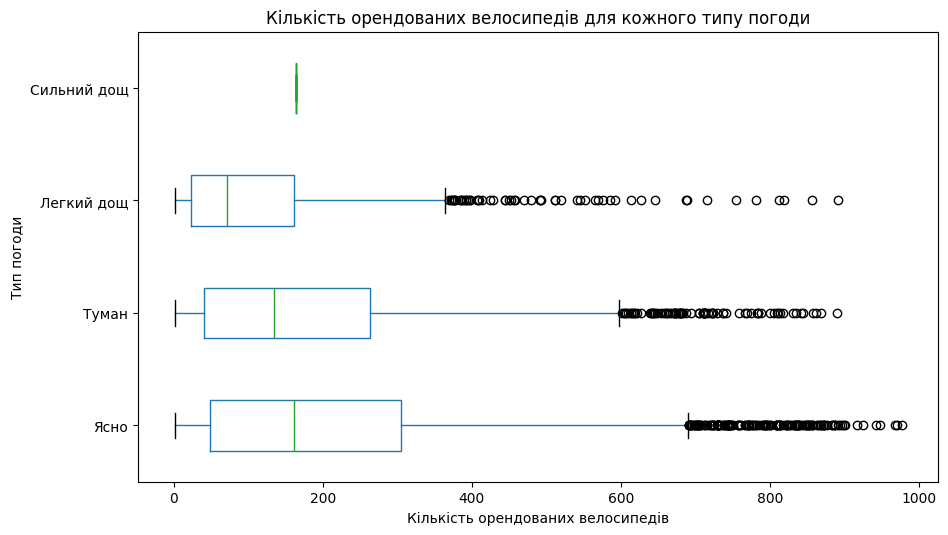

In [ ]:
rentals_by_weather = df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    grid = False,
    vert = False
)
plt.title('Кількість орендованих велосипедів для кожного типу погоди')
plt.suptitle('')
plt.ylabel('Тип погоди')
plt.xlabel('Кількість орендованих велосипедів')
rentals_by_weather.set_yticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.show()

1. Найбільший розкид даних спостерігається при ясній погоді.
2. Так, у даних чітко помітні викиди. Викиди є у категоріях «Ясно», «Туман» та «Легкий дощ».
3. Найвище медіанне значення оренди спостерігається при ясній погоді

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

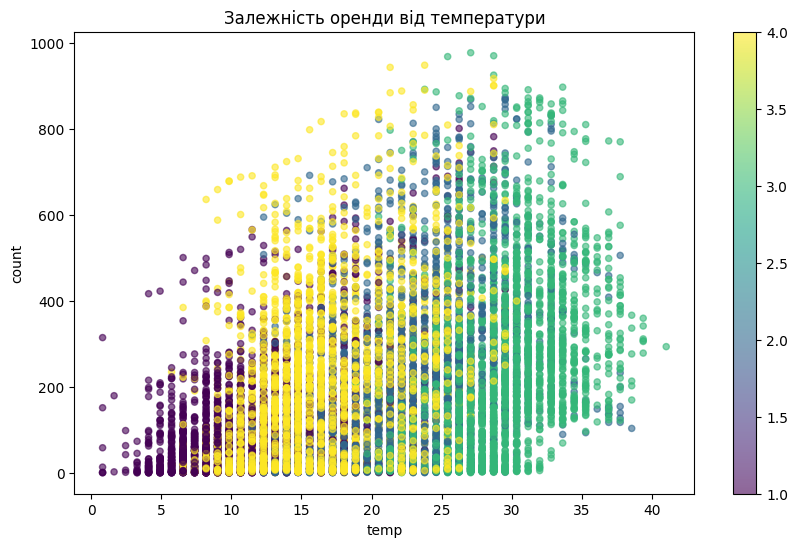

In [ ]:
df.plot.scatter(
    x='temp',
    y='count',
    c=df['season'],
    colormap='viridis',
    title='Залежність оренди від температури',
    figsize=(10, 6),
    alpha=0.6
)
plt.show()

Між температурою та кількістю оренди спостерігається пряма залежність. Це означає, що зі зростанням температури від $0\text{°C}$ до приблизно $25\text{-}30\text{°C}$ загальна кількість орендованих велосипедів схильна збільшуватися

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

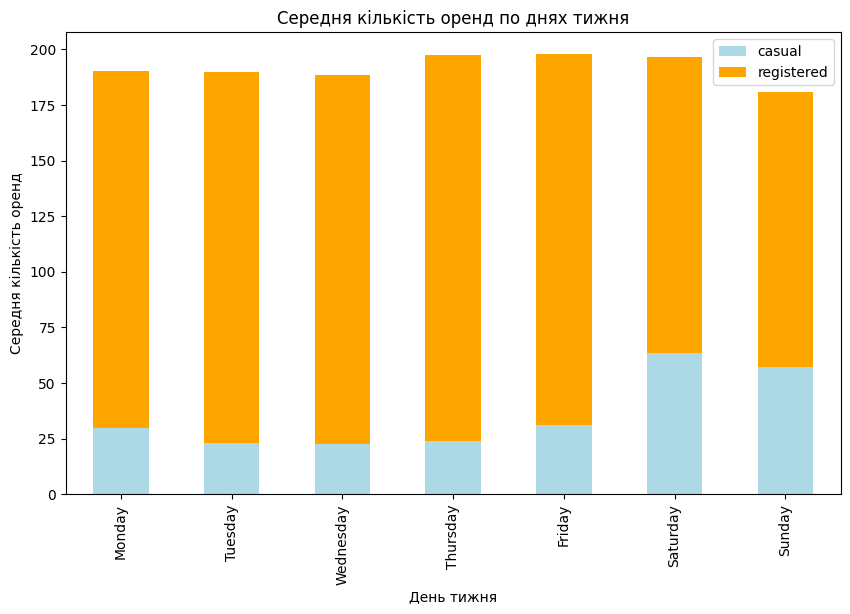

In [ ]:
avg_by_weekday = df.groupby('weekday')[['casual', 'registered']].mean()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_weekday = avg_by_weekday.reindex(weekday_order)

ax = avg_by_weekday.plot.bar(
    stacked=True,
    figsize=(10,6),
    color=['lightblue','orange'],
    title='Середня кількість оренд по днях тижня'
)

plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд')
plt.show()

1. Найвищі показники оренд від зареєстрованих користувачів спостерігаються у четвер (Thursday) та п'ятницю (Friday).
2. Висока активність у будні дні свідчить про те, що ця категорія використовує велосипеди як транспорт для поїздок на роботу або навчання.
Блакитні сектори значно збільшуються у суботу та неділю. Це вказує на те, що незареєстровані користувачі орендують велосипеди переважно для прогулянок та відпочинку у вільний час